## Demo Diffusion models generative AI

Author: alberto.suarez@uam.es
Date: 2025-03-02

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from functools import partial 

import torch
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

import diffusion_process as dfp

from diffusion_utilities import (
    plot_image_grid,
    plot_image_evolution,
    animation_images,
)


n_threads = torch.get_num_threads()
print('Number of threads: {:d}'.format(n_threads))

device ='cpu' 


Number of threads: 8


In [2]:
# Dataset MINST
data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)
print(type(data))


<class 'torchvision.datasets.mnist.MNIST'>


In [3]:
# Create a subset dataset composed of only images of one of the digits
digit = 3
indices_digit = torch.where(data.targets == digit)[0]  

data_train = Subset(data, indices_digit)
print(type(data_train))

<class 'torch.utils.data.dataset.Subset'>


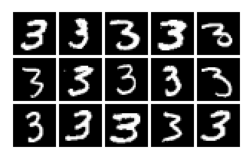

In [4]:
# Visualize training images
n_rows = 3 
n_cols = 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize =(3, 3),
    n_rows=n_rows, 
    n_cols=n_cols,
)

###  Diffusion process

In [ ]:
sigma = 25.0

def bm_drift_coefficient(x_t, t):
    return torch.zeros_like(x_t)

def bm_diffusion_coefficient(t, sigma):
    return sigma **t

def bm_mu_t(x_0, t):
    return x_0

def bm_sigma_t(t, sigma):
    return torch.sqrt(0.5 * (sigma**(2 * t) - 1.0) / np.log(sigma))
        
# Instanciate the Gaussian Diffusion Process
drift_coefficient = bm_drift_coefficient
diffusion_coefficient = partial(bm_diffusion_coefficient, sigma=sigma)
mu_t = bm_mu_t
sigma_t = partial(bm_sigma_t, sigma=sigma)



diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient,
    diffusion_coefficient,
    mu_t,
    sigma_t,
)


In [6]:
# Define the score model

from score_model import ScoreNet

score_model = torch.nn.DataParallel(
    ScoreNet(
        marginal_prob_std=partial(bm_sigma_t, sigma=sigma)
    )
)
score_model = score_model.to(device)

In [8]:
# Train model

from torch.optim import Adam
import torchvision.transforms as transforms
import tqdm

batch_size = 32

data_loader = DataLoader(
    data_train, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=n_threads,
)

# Set the learning rate for the optimizer
learning_rate = 1.0e-3
# Create the Adam optimizer, passing the model parameters and learning rate
optimizer = Adam(score_model.parameters(), lr=learning_rate)
# Define the number of epochs (iterations through the entire dataset)
n_epochs =  10
# Create a progress bar for the epochs using tqdm.notebook for Jupyter Notebook environments
tqdm_epoch = tqdm.trange(n_epochs)

# Loop through each epoch for model training
for epoch in tqdm_epoch: # Variable to accumulate the total loss for the current epoch
    avg_loss = 0.0  # Variable to track the number of items processed in the current epoch
    num_items = 0 # Variable to track the number of items processed in the current epoch

    # Loop through each batch of data in the data loader
    for x, y in data_loader:
        x = x.to(device)    
        loss = diffusion_process.loss_function(score_model, x)
        optimizer.zero_grad()
        loss.backward()    
        optimizer.step()
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]
        
    tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))

    torch.save(score_model.state_dict(), 'check_point.pth')

Average Loss: 38.002376: 100%|██████████| 10/10 [04:45<00:00, 28.59s/it]


In [ ]:
# Sample from the trained model

n_images = 3

# check_point = torch.load('model_digit_3_500_epochs.pth', map_location=device)
# score_model.load_state_dict(check_point)

def backward_drift_coefficient(x_t, t, diffusion_coefficient):    
    """ The reserve drift is given by:
            b(x_t, t)= -g(t)^2 *score_model(x_t,t)"""
    # Calcular el score: gradiente en cada paso de tiempo
    score= score_model(x_t, t) 

    g_t= diffusion_coefficient(t)
    g_t= g_t.view(-1,1,1,1)  #reshape

    # Calcula beta_t
    g2_t = g_t**2
    drift = -(g2_t * score)
    return drift


T = 1.0 
sigma_T = sigma_t(torch.tensor([T], device=device)).item()
image_T = sigma_T * torch.randn(n_images, 1, 28, 28, device=device)


with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        image_T,
        t_0 = T, 
        t_end = 1.0e-3,
        n_steps= 500,
        drift_coefficient=partial(
            backward_drift_coefficient,
            diffusion_coefficient=diffusion_coefficient,
        ),
        diffusion_coefficient=diffusion_coefficient, 
    )

print(type(synthetic_images_t))
print(synthetic_images_t.shape)

<class 'torch.Tensor'>
torch.Size([3, 1, 28, 28, 501])


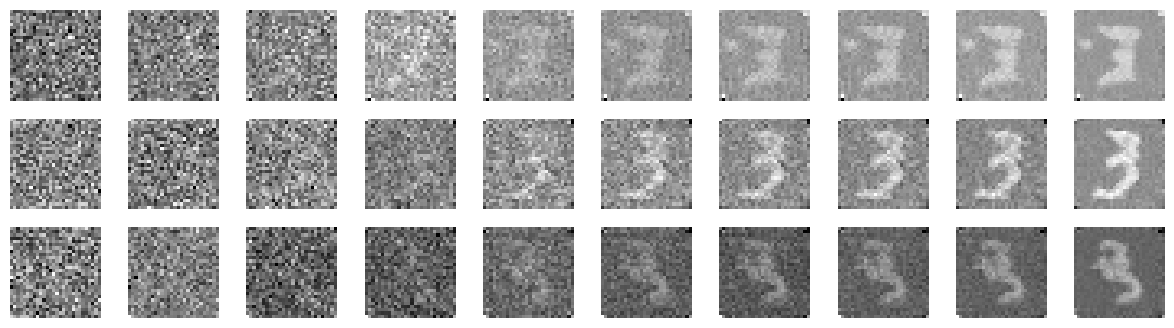

In [25]:
_ = plot_image_evolution(
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)
